# v02 — EDA & Feature Interpretation

범위: 항복 패배 label과 15분 feature의 관계.

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'src' / 'team2_surrender').exists()
)
os.chdir(ROOT)
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from IPython.display import display, Markdown, Image
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from team2_surrender.modeling import FEATURE_COLUMNS, TARGET_COLUMN, GROUP_COLUMN, make_group_split

RUN_ID = 'riot-scale-2600'
DATA_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features.csv'
VALIDATION_PATH = ROOT / 'data' / 'processed' / 'riot' / f'{RUN_ID}_team_features_validation_strict.json'
METRICS_PATH = ROOT / 'outputs' / 'metrics' / f'{RUN_ID}_model_comparison.json'
FIGURE_DIR = ROOT / 'reports' / 'figures' / RUN_ID
MODEL_DIR = ROOT / 'models' / RUN_ID
UPLOAD_VERIFICATION_PATH = ROOT / 'outputs' / 'verification' / f'supabase_upload_{RUN_ID}.json'

REQUIRED_PATHS = [DATA_PATH, VALIDATION_PATH, METRICS_PATH, FIGURE_DIR, MODEL_DIR, UPLOAD_VERIFICATION_PATH]

for path in REQUIRED_PATHS:
    print(f'{path.relative_to(ROOT)} -> {path.exists()}')

missing_paths = [path for path in REQUIRED_PATHS if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(str(path.relative_to(ROOT)) for path in missing_paths)
    raise FileNotFoundError(
        'Missing required analysis artifacts:\n'
        f'{missing_text}\n\n'
        'Run: python scripts/prepare_jupyter_analysis_artifacts.py'
    )

data/processed/riot/riot-scale-2600_team_features.csv -> True
data/processed/riot/riot-scale-2600_team_features_validation_strict.json -> True
outputs/metrics/riot-scale-2600_model_comparison.json -> True
reports/figures/riot-scale-2600 -> True
models/riot-scale-2600 -> True
outputs/verification/supabase_upload_riot-scale-2600.json -> True


In [2]:
df = pd.read_csv(DATA_PATH)
y = df[TARGET_COLUMN].astype(bool).astype(int)
print('rows:', len(df))
print('matches:', df[GROUP_COLUMN].nunique())
print('positive rows:', int(y.sum()))
print('positive rate:', round(float(y.mean()), 4))
display(df.head())

rows: 5050
matches: 2525
positive rows: 870
positive rate: 0.1723


,match_id,team_id,feature_version,team_surrendered,queue_id,game_version,game_duration_sec,collected_at,gold_diff_15,kill_diff_15,tower_diff_15,dragon_diff_15,rift_herald_diff_15,cs_diff_15,avg_level_diff_15,first_blood,first_tower,ward_placed_diff_15,ward_kill_diff_15
0,KR_8143703690,100,v1_15min,True,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,-270,-6,1,-1,0,8,-0.4,1,1,-7,2
1,KR_8143703690,200,v1_15min,False,420,16.6.756.931,1382,2026-05-14T19:59:29+00:00,270,6,-1,1,0,-8,0.4,-1,-1,7,-2
2,KR_8143357958,100,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,2064,3,0,-2,0,9,0.2,-1,-1,1,-2
3,KR_8143357958,200,v1_15min,False,420,16.6.756.931,2232,2026-05-14T19:59:29+00:00,-2064,-3,0,2,0,-9,-0.2,1,1,-1,2
4,KR_8143287893,100,v1_15min,False,420,16.6.756.931,1473,2026-05-14T19:59:29+00:00,-4374,-9,0,-2,0,-74,-0.6,-1,0,1,-6


## 1. Label distribution

,team_rows
negative,4180
positive,870


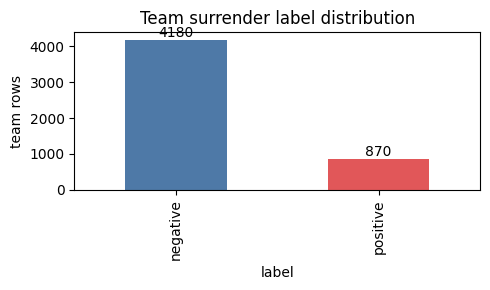

In [3]:
label_counts = y.value_counts().sort_index()
label_counts.index = ['negative', 'positive']
display(label_counts.to_frame('team_rows'))
fig, ax = plt.subplots(figsize=(5, 3))
label_counts.plot(kind='bar', ax=ax, color=['#4e79a7', '#e15759'])
ax.set_title('Team surrender label distribution')
ax.set_xlabel('label')
ax.set_ylabel('team rows')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 2. Positive vs Negative feature means

,negative_mean,positive_mean,positive_minus_negative
gold_diff_15,739.053828,-3550.856322,-4289.910150
cs_diff_15,6.805024,-32.695402,-39.500426
kill_diff_15,1.269139,-6.097701,-7.366840
ward_placed_diff_15,0.294737,-1.416092,-1.710829
tower_diff_15,0.185167,-0.889655,-1.074823
ward_kill_diff_15,0.158373,-0.760920,-0.919293
dragon_diff_15,0.132057,-0.634483,-0.766540
avg_level_diff_15,0.103684,-0.498161,-0.601845
first_tower,0.098086,-0.471264,-0.569350
first_blood,0.038278,-0.183908,-0.222186


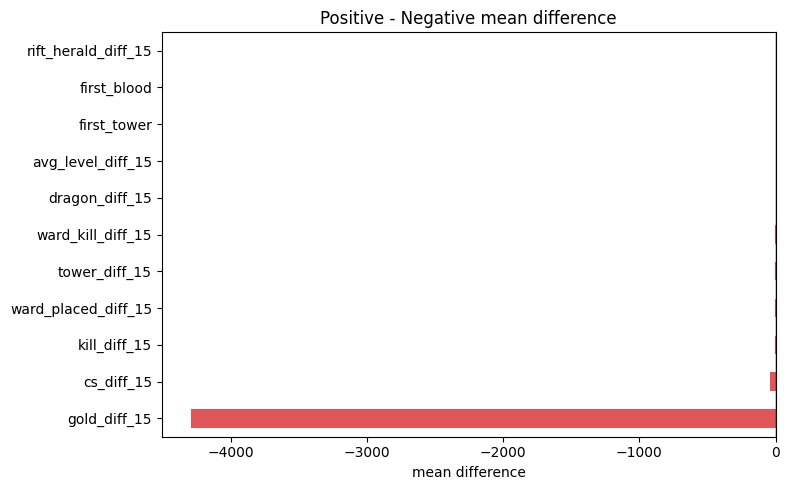

In [4]:
class_means = df.groupby(y)[FEATURE_COLUMNS].mean().T
class_means.columns = ['negative_mean', 'positive_mean']
class_means['positive_minus_negative'] = class_means['positive_mean'] - class_means['negative_mean']
display(class_means.sort_values('positive_minus_negative'))

plot_df = class_means['positive_minus_negative'].sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
plot_df.plot(kind='barh', ax=ax, color=['#e15759' if v < 0 else '#59a14f' for v in plot_df])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Positive - Negative mean difference')
ax.set_xlabel('mean difference')
plt.tight_layout()
plt.show()

## 3. Surrender rate by gold/kill buckets

,gold_diff_15_bucket,team_surrendered
0,"(-20000.001, -8000.0]",0.613793
1,"(-8000.0, -5000.0]",0.463869
2,"(-5000.0, -3000.0]",0.312721
3,"(-3000.0, -1000.0]",0.225513
4,"(-1000.0, 0.0]",0.122288
5,"(0.0, 1000.0]",0.116371
6,"(1000.0, 3000.0]",0.075171
7,"(3000.0, 5000.0]",0.028269
8,"(5000.0, 8000.0]",0.009324
9,"(8000.0, 20000.0]",0.000000


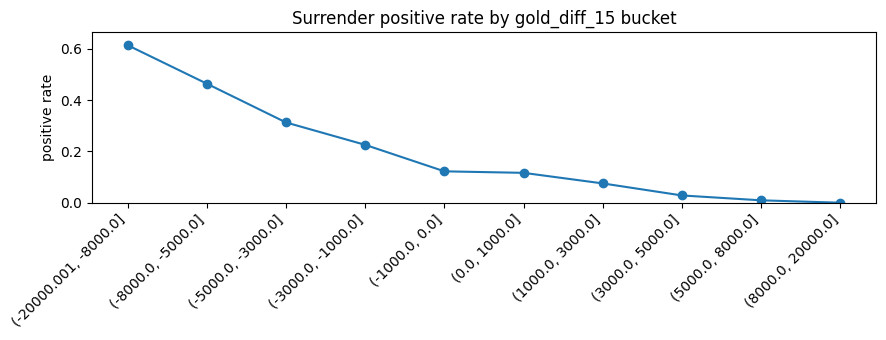

,kill_diff_15_bucket,team_surrendered
0,"(-50.001, -15.0]",0.607692
1,"(-15.0, -10.0]",0.468421
2,"(-10.0, -5.0]",0.287529
3,"(-5.0, -2.0]",0.206579
4,"(-2.0, 0.0]",0.142315
5,"(0.0, 2.0]",0.096591
6,"(2.0, 5.0]",0.074965
7,"(5.0, 10.0]",0.036000
8,"(10.0, 15.0]",0.003279
9,"(15.0, 50.0]",0.000000


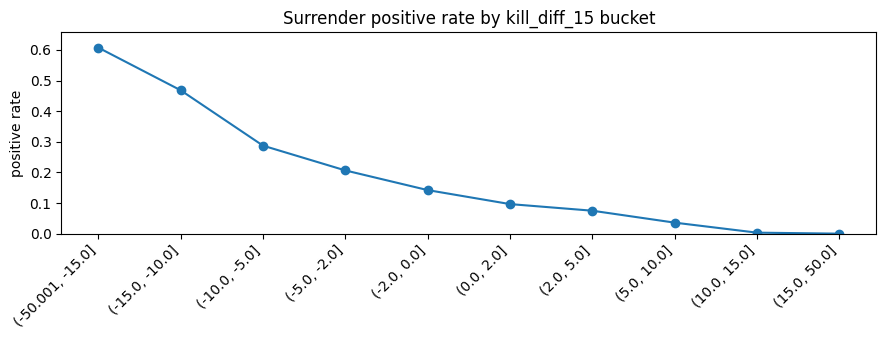

In [5]:
for feature, bins in {
    'gold_diff_15': [-20000, -8000, -5000, -3000, -1000, 0, 1000, 3000, 5000, 8000, 20000],
    'kill_diff_15': [-50, -15, -10, -5, -2, 0, 2, 5, 10, 15, 50],
}.items():
    tmp = df.copy()
    tmp[f'{feature}_bucket'] = pd.cut(tmp[feature], bins=bins, include_lowest=True)
    rate = tmp.groupby(f'{feature}_bucket', observed=False)[TARGET_COLUMN].mean().reset_index()
    display(rate)
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(range(len(rate)), rate[TARGET_COLUMN], marker='o')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate[f'{feature}_bucket'].astype(str), rotation=45, ha='right')
    ax.set_title(f'Surrender positive rate by {feature} bucket')
    ax.set_ylabel('positive rate')
    ax.set_ylim(0, max(0.5, float(rate[TARGET_COLUMN].max()) + 0.05))
    plt.tight_layout()
    plt.show()

## 4. Existing pipeline EDA figures

figure count: 7


### 01_class_balance.png

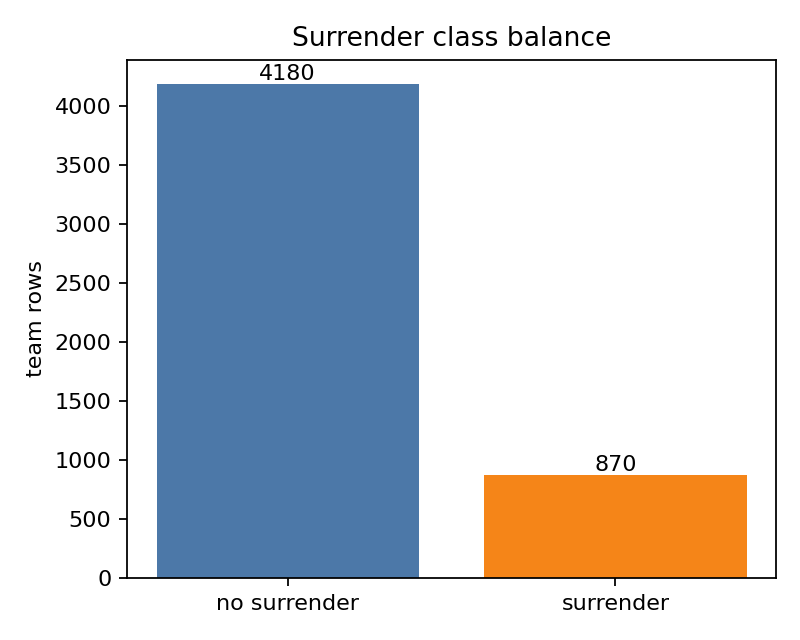

### 02_game_duration_distribution.png

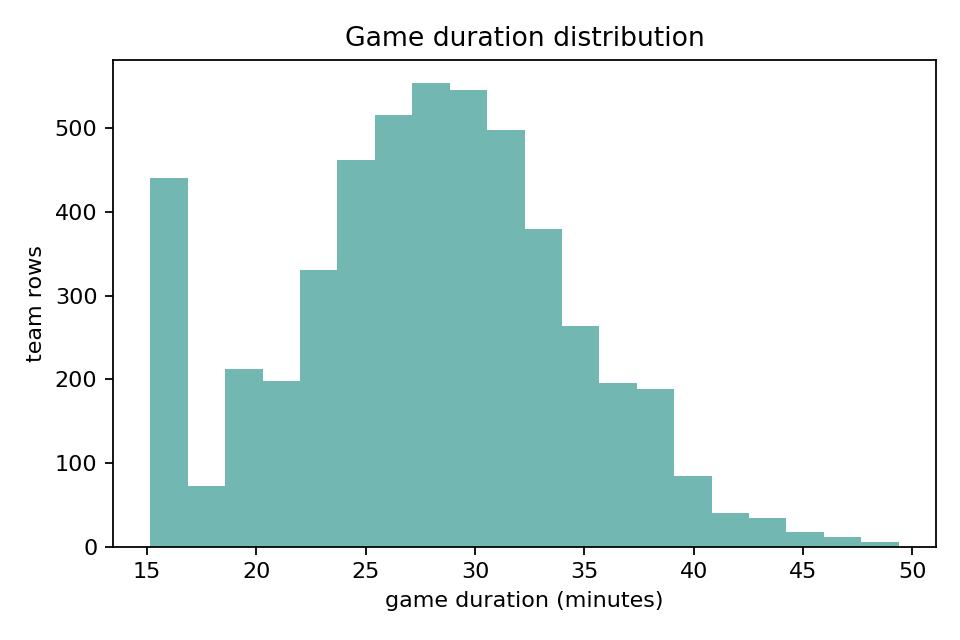

### 03_surrender_rate_by_gold_diff.png

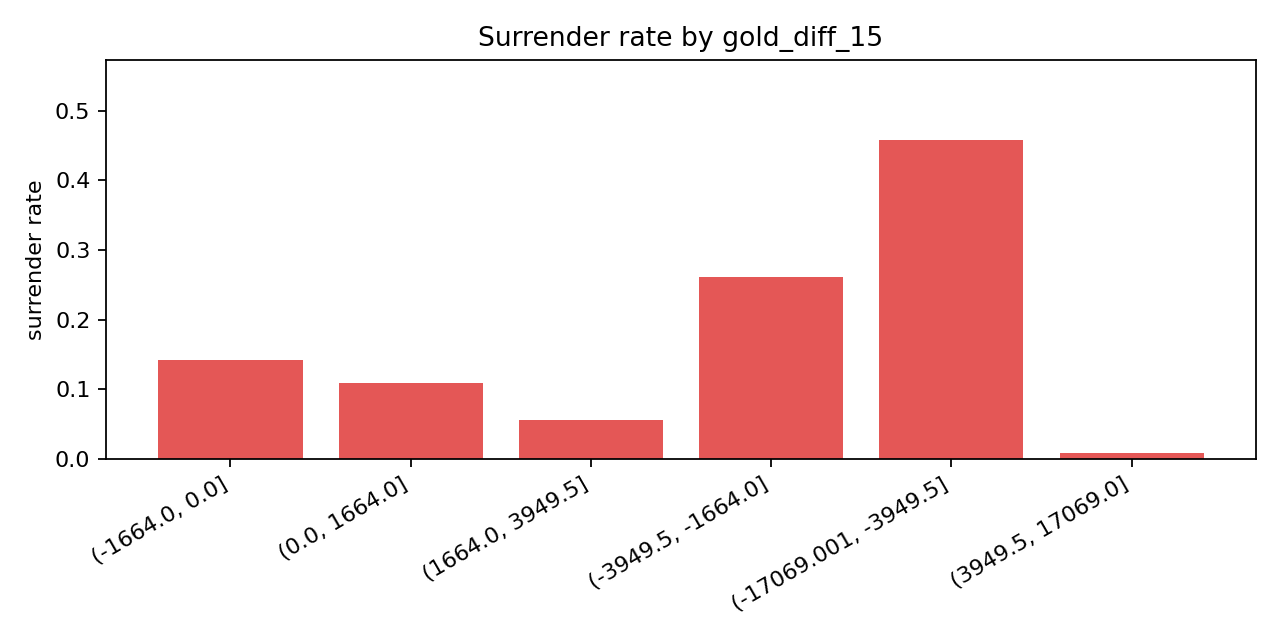

### 04_surrender_rate_by_kill_diff.png

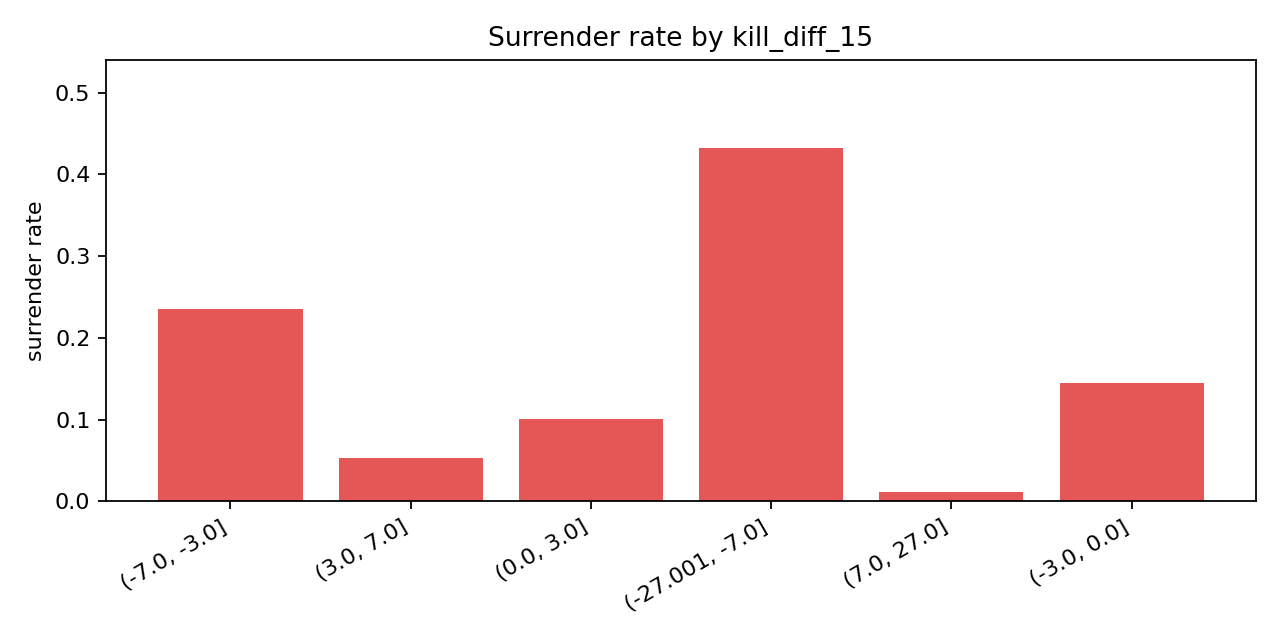

### 05_objective_differences_by_label.png

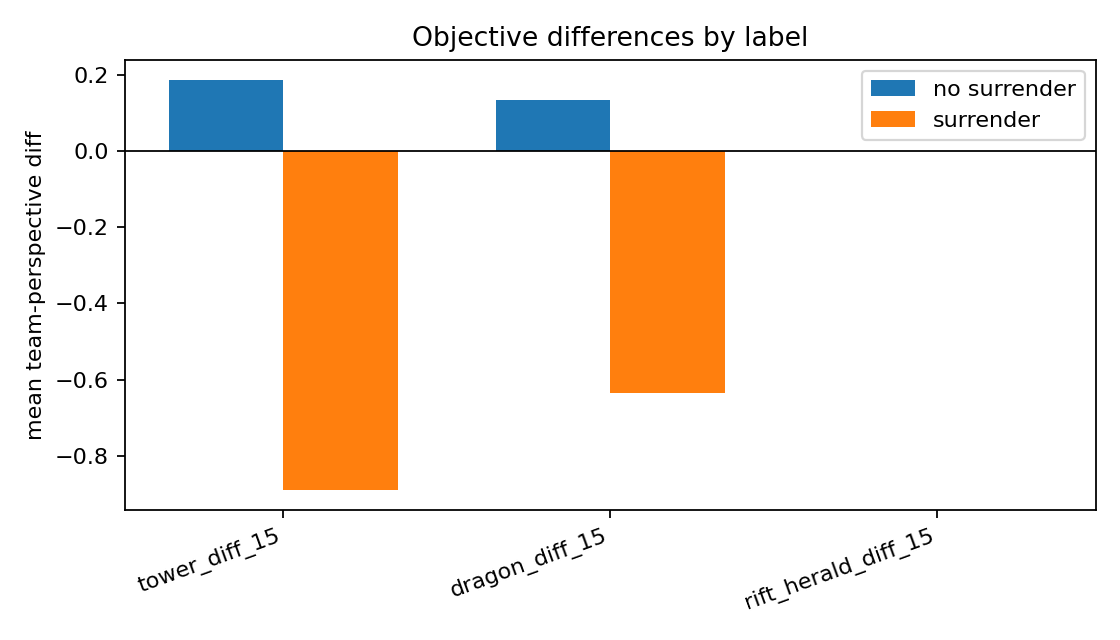

### 06_feature_correlation_heatmap.png

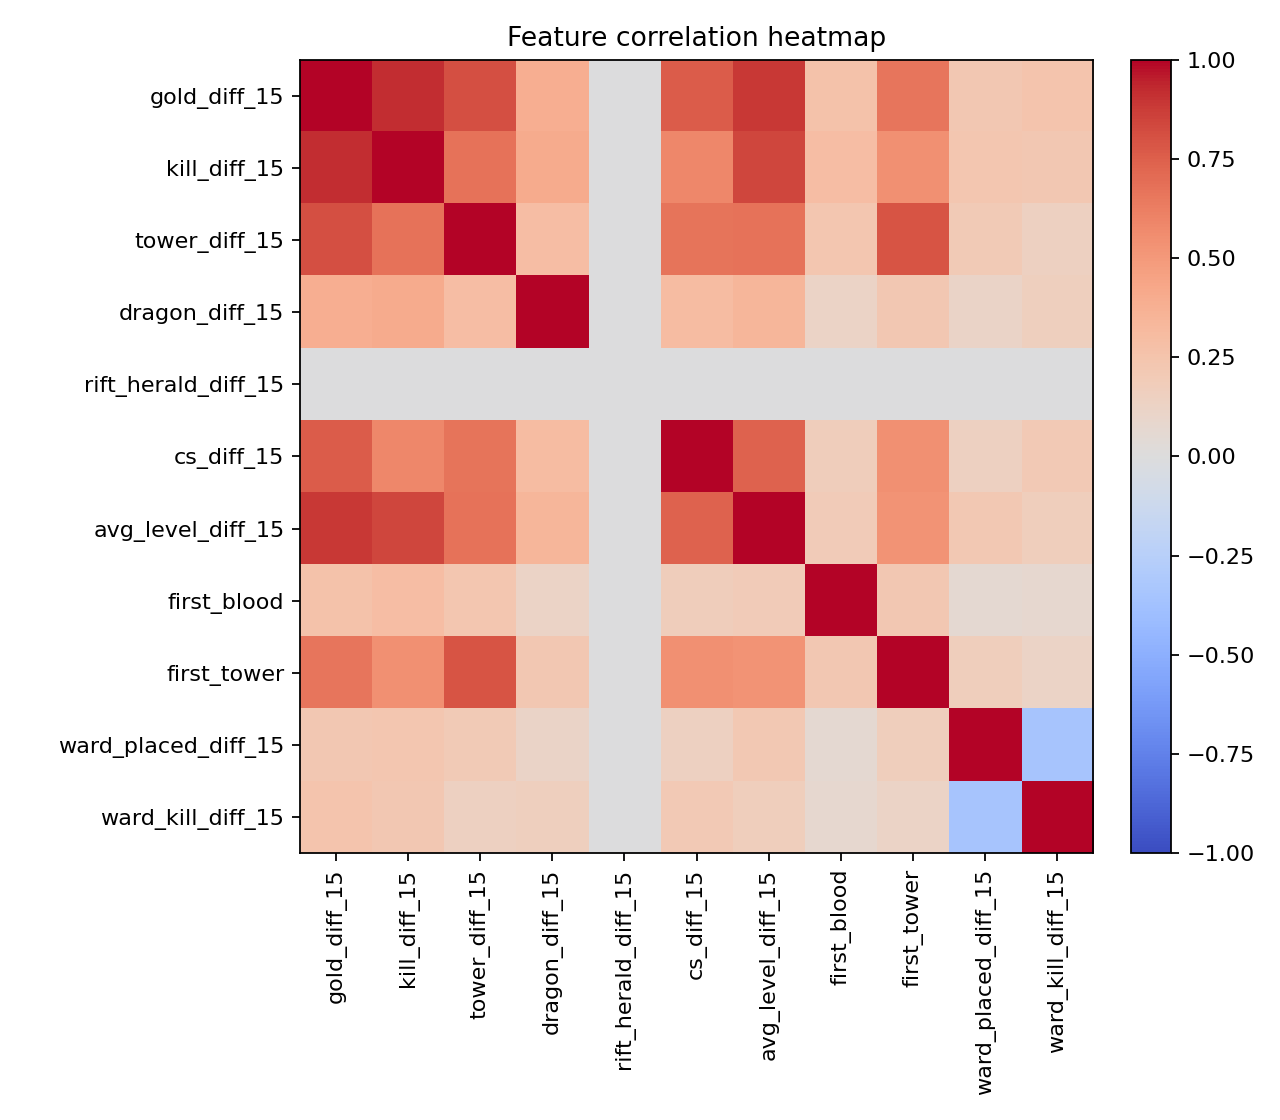

### 07_model_metric_comparison.png

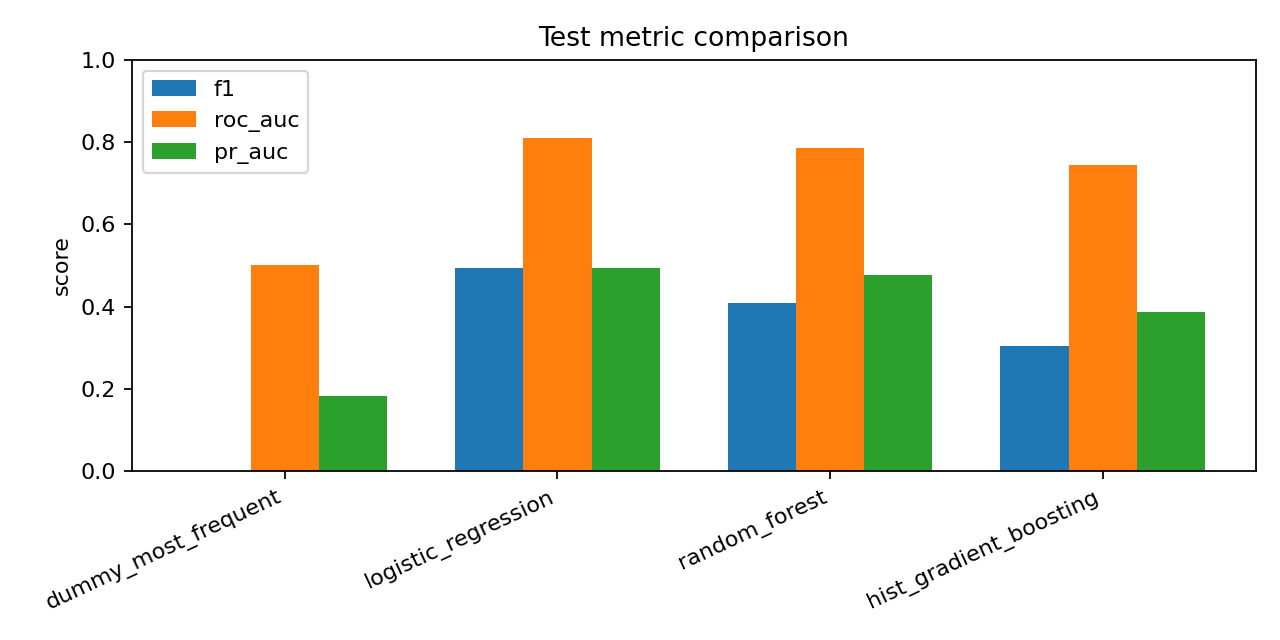

In [6]:
figure_paths = sorted(FIGURE_DIR.glob('*.png'))
print('figure count:', len(figure_paths))
for path in figure_paths:
    display(Markdown(f'### {path.name}'))
    display(Image(filename=str(path)))

## v02 notes

- Positive team은 평균적으로 15분 지표에서 더 불리함.
- gold/kill/cs/tower/dragon 격차가 label 차이를 크게 설명함.